# Ondas Electromagnéticas
Método FDTD
El método **Finite Difference Tie Domain** se usa para resolver numércamente las ecuaciones de Maxwell mediante diferencias finitas en espacio y tiempo
1. Discretizamos el tiempo y el espacio
2. Definimos los campos en una malla
3. Avanzamos la solución paso a paso en el tiempo
La aplicamos a vibraciones en cuerdas, la ecuación de Schrödinger, y propagación de ondas.

Para este caso estamos trabajando con dos campos acoplados, perpendiulares y que se propagan en una tercera dirección z:
$$\vec{E} = E_x(z,t)\hat{x};\qquad\vec{H} = H_y(z,t)\hat{y}$$
Con la dirección de flujo de energía en la dirección z según el vector de pointing:
$$\vec{S}=\vec{E}\times\vec{H}$$

Las ecuaciones de Maxwell en el vacío son:
$$\nabla\cdot\vec{E} = 0\quad;\quad\nabla\cdot\vec{H}=0\\
\nabla\times\vec{E}=\frac{\partial\vec{H}}{\partial t}\quad;\quad\nabla\times\vec{H}=\mu_0\epsilon_0\frac{\partial\vec{E}}{\partial t}$$

Para los campos considerados, las ecuaciones toman la forma:
$$\frac{\partial E_x(z,t)}{\partial z} = -\mu_0\frac{\partial H_y(z,t)}{\partial t}\quad;\quad \frac{\partial H_y(z,t)}{\partial z} = -\epsilon_0\frac{\partial E_x(z,t)}{\partial t}$$

Discretizando:
$$\frac{\partial E(x,t)}{\partial t} = \frac{E(z,t+h/2)-E(z,t-h/2)}{\Delta t}\\ .\\
\frac{\partial E}{\partial z} = \frac{E(z+h/2,t) - E(z-h/2,t)}{\Delta z}$$

# Mallado
El mallado ahora tendrá una frma distinta al anterior, dado que las derivadas de primer orden no ocupan estados movidos completamente, y hablamos de pasos a medias hacia el futuro. La discretización:
$$z = k\Delta z\qquad t = n\Delta t\\
E_X(z,t)\rightarrow E_x^{k, n}\qquad H_z(z,t)\rightarrow H^{k,n}$$

$$E_x^{k,n+1} = E_x^{k,n-1/2} - \beta(H_y^{k+1/2,n}-H_y^{k-1/2,n})\\.\\
H_y^{k+1/2,n+1} = H_y^{k+1/2,n-1/2} + \beta(E_x^{k+1,n}-E_x^{k,n})$$
Con $1/2 > \beta$. El algoritmo a seguir:
- Inicializar los campos H y E
- Actualizar Ex
- Actualizar Hy
- Aplicar condiciones de frontera
- Graficar
- Repetir

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [11]:
#parámetros físicos
c = 1
Nz = 4000 #puntos espaciales
dz = 1 #paso expacial
beta = 0.4 #condición de courant
dt = beta * dz / c
lambda0 = 120
k = 2 * np.pi / lambda0
steps  = 600
phase = 0

Ex = np.zeros(Nz)
Hy = np.zeros(Nz)

#pulso inicial gausiano
z = np.arange(Nz)

Ex = np.exp(-((z - 80) / 15) ** 2) * np.sin(k * z)
Hy = np.exp(-((z - 80) / 15) ** 2) * np.sin(k * z + phase )



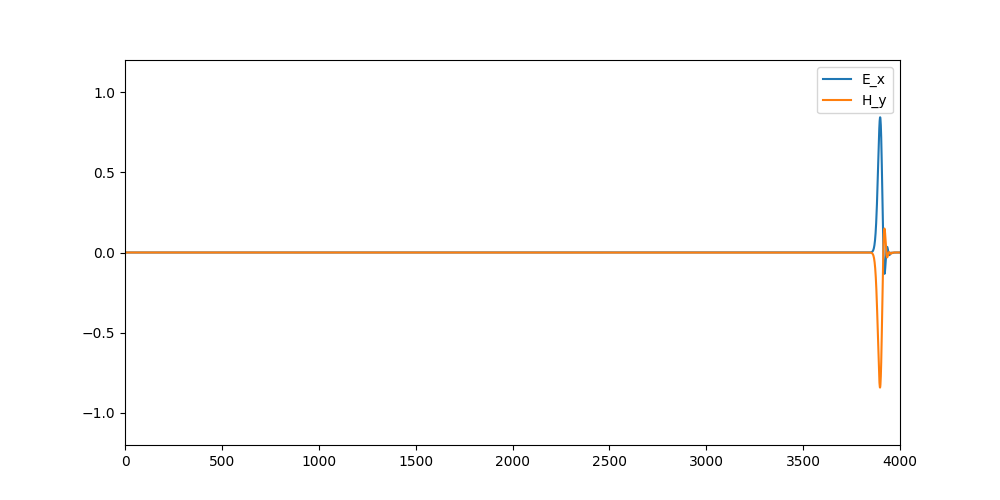

In [16]:
fig, ax = plt.subplots(figsize = (10, 5))

lineE, = ax.plot(z, Ex, label = r'E_x')
lineH, = ax.plot(z, Hy, label = r'H_y')

ax.set_xlim(0, Nz)
ax.set_ylim(-1.2, 1.2)

ax.legend()

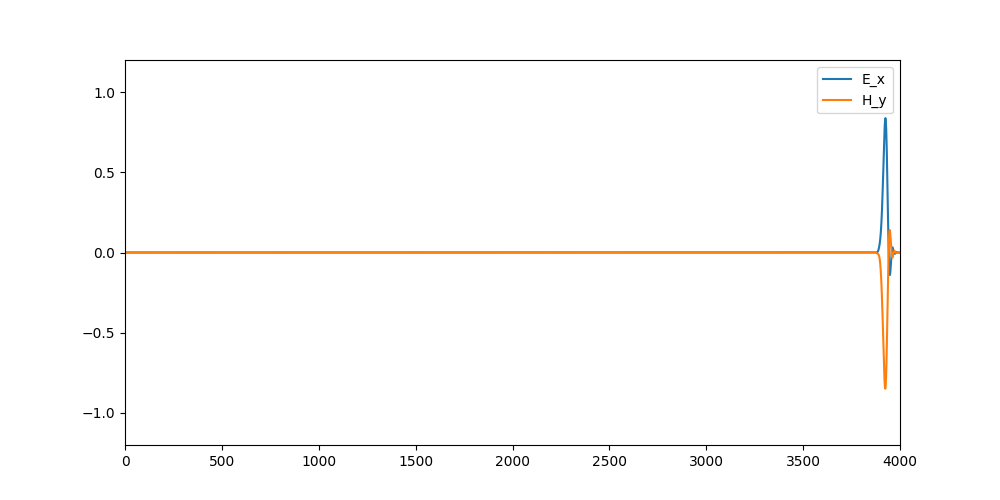

In [15]:
def update(frame):

    global Ex, Hy

    #actualizar Ex
    Ex[1:-1] += beta * (Hy[:-2] - Hy[1:-1])

    #Actualizar Hy
    Hy[1:-1] += beta * (Ex[1:-1] - Ex[2:])

    #condiciones de frontera
    Ex[0] = Ex[-1] = 0
    Hy[0] = Hy[-1] = 0

    lineE.set_ydata(Ex)
    lineH.set_ydata(Hy)

    return lineE, lineH
ani = FuncAnimation(fig, update, frames = steps, interval = 20, blit = True)
plt.show()